In [1]:
from swo_lanczos_2023_09_09 import output_dir
from misc_utils import read_jsonl_to_df
import seaborn as sns
import matplotlib.pyplot as plt

2023-09-10 13:24:04.994 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-09-10 13:24:04.996 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-09-10 13:24:05.037 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
overlaps_df = read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")).fillna({'epochs': 100})
# losses_df = read_jsonl_to_df(output_dir.glob("./*/losses.jsonl")).assign(
#     global_epoch=lambda df: df["epoch"] + df["iteration"] * (df["epoch"].max() + 1)
# )

In [3]:
def to(type_, cols):
    def wrapper(df):
        df = df.copy()
        if isinstance(cols, str):
            cols_ = [cols]
        else:
            cols_ = cols
        for col in cols_:
            df[col] = df[col].astype(type_)
        return df
    return wrapper

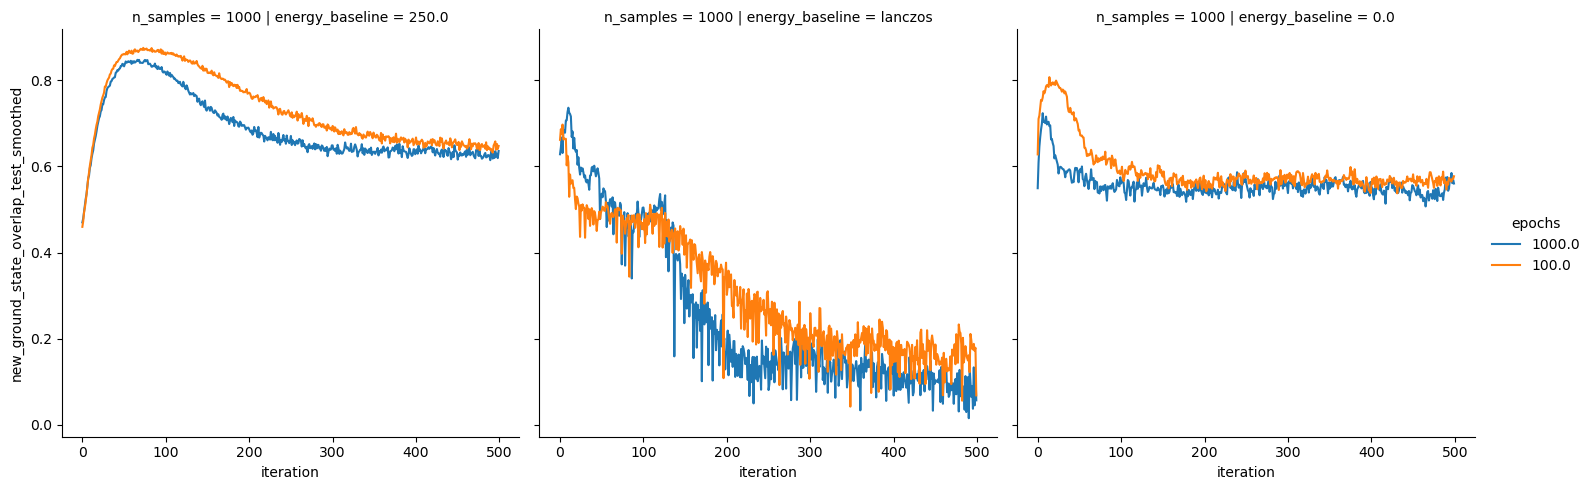

In [8]:
sns.relplot(
    data=overlaps_df.fillna({"energy_baseline": 'lanczos'})
    .assign(
        new_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            ["lattice", "n_samples", "energy_baseline"]
        )["new_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=1, center=True).mean()
        )
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="new_ground_state_overlap_test_smoothed",
    hue="epochs",
    col="energy_baseline",
    row="n_samples",
    kind="line",
)

In [ ]:
overlaps_df

,iteration,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,new_ground_state_overlap_train,new_ground_state_overlap_test,alpha,run,mode,n_samples,lattice,energy_baseline,n_spins,epochs
0,0,0.460177,0.451269,0.777352,0.777922,0.628440,-0.863657,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
1,1,0.688698,0.622368,0.888058,0.887952,0.644334,-0.715098,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
2,2,0.720192,0.672630,0.879989,0.881688,0.667056,-0.549112,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
3,3,0.822422,0.686204,0.939404,0.940045,0.631306,-0.726745,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
4,4,0.809950,0.695011,0.927723,0.926465,0.685047,-0.539695,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,495,0.818403,0.199005,0.758271,0.758354,0.174930,-0.663930,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
783,496,0.731347,0.189546,0.819627,0.819642,0.187885,-0.524637,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
784,497,0.863109,0.194170,0.659473,0.659463,0.171711,-0.880196,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
785,498,0.313704,0.186600,0.897028,0.897049,0.178817,-0.743507,0,lanczos,1000,KagomeLattice2x3,None,18,100.0


In [ ]:
# (ggplot(overlaps_df.dropna(subset=['energy_baseline']), aes(x='iteration', y='new_ground_state_overlap_test', color='energy_baseline'))
#     + geom_point() + geom_smooth(method='loess')
#     + facet_grid('n_samples ~ lattice') + theme_minimal())

In [ ]:
# sns.relplot(
#     overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="energy_baseline",
#     kind="line",
#     row="lattice",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


In [ ]:
# sns.relplot(
#     overlaps_df.query("mode == 'power'"),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="lattice",
#     kind="line",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')
